# Simple Landscape

In gradient ascent, we use this formula to re-calculate the start points:

Do xnew = x + η · ∇f(x) where η is a learning rate and ∇ denotes the gradient
operator

In [3]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import numpy as np
import random as rand

In [4]:
"SIMPLE LS"
# Definition of Simple landscape
def SimpleLandscape(x, y):
    return np.where(1-np.abs(2*x)>0,1-np.abs(2*x)+x+y,x+y)
    
# Definition of gradient of Simple landscape
def SimpleLandscapeGrad(x, y):
    g = np.zeros(2)
    if 1 - np.abs(2 * x) > 0:
        if x < 0:
            g[0] = 3
        elif x == 0:
            g[0] = 0
        else:
            g[0] = -1
    else:
        g[0] = 1
    g[1] = 1
    return g

In [5]:
# Function to draw a surface (equivalent to ezmesh in Matlab)
# See argument cmap of plot_surface instruction to adjust color map (if so desired)
def DrawSurface(fig, varxrange, varyrange, function):
    
    ax = fig.gca(projection='3d')
    xx, yy = np.meshgrid(varxrange, varyrange, sparse=False)
    z = function(xx, yy)
    surface = ax.plot_surface(xx, yy, z, alpha = 0.3,cmap=cm.coolwarm,
                       linewidth=100, antialiased=True) # color map can be adjusted, or removed! 
    fig.colorbar(surface, shrink=0.5, aspect=5)
    fig.canvas.draw()
    return ax

## Gradient Ascent

In [6]:
# Function implementing gradient ascent
def GradAscent(StartPt,NumSteps,LRate,GlobalOptimum, x, y):
    
    prevHeight = -99 #keep track of previous height
    CapIteration = 0.0 #keep track of iteration that reaches a constant height
    StopCapCount = False #counter to control if statement
    
    # iterate a number of steps
    for i in range(NumSteps):
        
        # TO DO: Calculate the 'height' at StartPt using SimpleLandscape
        height = SimpleLandscape(StartPt[0],StartPt[1])

        #capture height so that we can track which height becomes constant
        if height != prevHeight:
            prevHeight = height
        
        #if height becomes constant, capture the iteration number
        elif height == prevHeight and StopCapCount == False:
            CapIteration = i+1
            StopCapCount = True
        
        # TO DO: Plot point on the landscape  
        ax.scatter(StartPt[0], StartPt[1], height, zorder=2)

        # TO DO: Calculate the gradient at StartPt using SimpleLandscapeGrad
        gradient = SimpleLandscapeGrad(StartPt[0],StartPt[1])

        # TO DO: Calculate the new point and update StartPt
        StartPt += StartPt + LRate * gradient

        # Ensure StartPt is within the specified bounds
        StartPt = np.maximum(StartPt,[x,x])
        StartPt = np.minimum(StartPt,[y,y])

        #if GO is reached return 1, print and break
        if height == GlobalOptimum:
            print("Actual Height ", height, " reached in ", 
                  CapIteration, " iterations")
            return 1, i
            break
    
    #if GO was not reached in numSteps, print and return 0
    print("Actual Height ", height, " reached in ", 
                  CapIteration, " iterations")
    return 0, NumSteps

## Implementation

inital starting point (x,y): [0.00166, 1.74181]
Target Height:  4
Actual Height  4.0  reached in  0.0  iterations
0/1=Not/Reached, Iterations:  (1, 11)


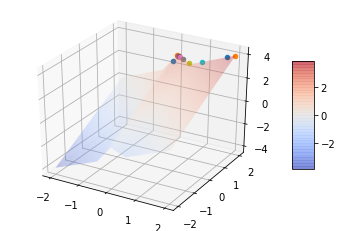

In [7]:
# Driver
# Plot the landscape (un/comment relevant line)
plt.ion()
fig = plt.figure()
ax = DrawSurface(fig, np.arange(-2,2.025,0.025), np.arange(-2,2.025,0.025), SimpleLandscape)

# maximum number of iterations and learning rate
NumSteps=50
LRate=0.01

# TO DO: choose a random starting point with x and y in the range (-2, 2)
x = -2
y = 2
StartPt = [round(rand.uniform(x,y),5),round(rand.uniform(x,y),5)]
GlobalOptimum = abs(x)+abs(y)
print("inital starting point (x,y):", StartPt)
print("Target Height: ",GlobalOptimum)

# Find maximum
print("0/1=Not/Reached, Iterations: ",
      GradAscent(StartPt,NumSteps,LRate,GlobalOptimum,x,y))

## Gradient Ascent 2

In [8]:
# Function implementing gradient ascent
def GradAscent(xx,yy,NumSteps,LRate,x, y): #,NumGenerations
    
    StartPt = [] #start point will become an array or (x,y) after for loop
    prevHeight = -99 #keep track of previous height
    CapIteration = 0.0 #keep track of iteration that reaches a constant height
    StopCapCount = False #counter to control if statement
    height = 0

    # iterate a number of steps  
    for i in range(len(xx)):
        for j in range(len(yy)):
            StartPt = [xx[i][j],yy[i][j]]

            for k in range(NumSteps):
                #Calculate 'height' at StartPt
                height = SimpleLandscape(StartPt[0],StartPt[1])

                #capture height so that we can track which height becomes constant
                if height != prevHeight:
                    prevHeight = height

                #if height becomes constant, capture the iteration number
                elif height == prevHeight and StopCapCount == False:
                    CapIteration = i+1
                    StopCapCount = True

                # TO DO: Plot point on the landscape 
                ax.scatter(StartPt[0], StartPt[1], height)

                #Calculate gradient at StartPt
                gradient = SimpleLandscapeGrad(StartPt[0],StartPt[1])

                # TO DO: Calculate the new point and update StartPt
                StartPt += StartPt + LRate * gradient

                # Ensure StartPt is within the specified bounds
                StartPt = np.maximum(StartPt,[x,x])
                StartPt = np.minimum(StartPt,[y,y])
        
    return 0, NumSteps

## Implementation 2

(0, 20)

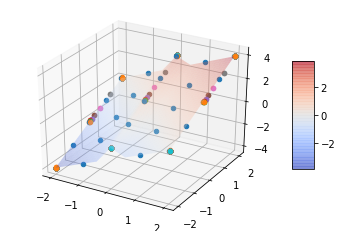

In [9]:
# Driver
#Keeping same landscape/starting point ranges as before
x = -2
c = 0.025
y = 2 + c

# Ploting the landscape with same function as before
#plt.ion()
fig = plt.figure()
ax = DrawSurface(fig, np.arange(x,y,c), np.arange(x,y,c), SimpleLandscape)

# maximum number of iterations and learning rate
NumSteps=20
LRate=0.01
#NumGenerations=50

#create arrays of x, y coordinates in specified range (x,y)
xvals = np.array([-2, -1, 0, 1, 2])
yvals = np.array([-2, -1, 0, 1, 2])
xx, yy = np.meshgrid(xvals, yvals)

GradAscent(xx,yy,NumSteps,LRate,x,y)

## Hill Climbing

In [10]:
# TO DO: Mutation function
# Returns a mutated point given the old point and the range of mutation
def Mutate(OldPt,MaxMutate):
    
    # TO DO: Select a random distance MutDist to mutate in the range (-MaxMutate,MaxMutate)
    MutDist = rand.uniform(-MaxMutate, MaxMutate)
    
    # TO DO: Randomly choose which element of OldPt to mutate and mutate by MutDist
    MutatedPt = rand.choice(OldPt) + MutDist
    
    return MutatedPt        

In [11]:
# Function implementing hill climbing
def HillClimb(StartPt,NumSteps,MaxMutate,GlobalOptimum,x,y):
    
    prevHeight = -99
    CapIteration = 0.0
    StopCapCount = False
    
    for i in range(NumSteps):
        # TO DO: Calculate the 'height' at StartPt using SimpleLandscape
        height = SimpleLandscape(StartPt[0],StartPt[1])
        print(height)
        
        if height != prevHeight:
            prevHeight = height
            CapIteration = i+1
            
        elif height == prevHeight and StopCapCount == False:
            CapIteration = i+1
            StopCapCount = True
        
        # TO DO: Plot point on the landscape using height
        ax.scatter(StartPt[0], StartPt[1], height)
        
        # Mutate StartPt into NewPt
        # Use copy because Python passes variables by references
        NewPt = Mutate(np.copy(StartPt),MaxMutate)
        
        # Ensure NewPt is within the specified bounds
        NewPt = np.maximum(NewPt,[x,x])
        NewPt = np.minimum(NewPt,[y,y])
               
        # TO DO: Calculate the height of the new point
        NewHeight = SimpleLandscape(NewPt[0],NewPt[1])
        
        # TO DO: Decide whether to update StartPt or not
        if NewHeight > height:
            StartPt = NewPt
        
        # TEST: if height reaches GO then break
        # add a 1 to i to get real-time height calculations
        if height == GlobalOptimum:
            print("Actual Height ", height, " reached in ", 
                  CapIteration-1, " iterations")
            return 1, i
            break
    
    print("Actual Height ", height, " reached in ", 
                  CapIteration-1, " iterations")
    return 0, NumSteps

## Implementation

inital starting point (x,y): [-0.91402897679647, 0.35912713651482386]
Target Height:  4
-0.5549018402816461
-0.5549018402816461
0.7824318854136507
0.7824318854136507
0.7824318854136507
1.6366878383811163
1.6366878383811163
2.788919083968354
2.788919083968354
2.788919083968354
2.788919083968354
2.788919083968354
2.788919083968354
4.0
Actual Height  4.0  reached in  13  iterations
0/1=Not/Reached, Iterations:  (1, 13)


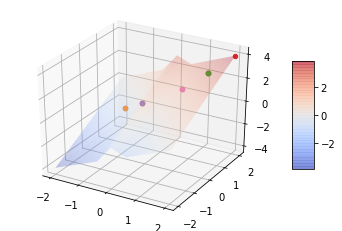

In [12]:
# Driver
# Plot the landscape (un/comment relevant line)
plt.ion()
fig = plt.figure()
ax = DrawSurface(fig, np.arange(-2,2.025,0.025), np.arange(-2,2.025,0.025), SimpleLandscape)

# Enter maximum number of iterations of the algorithm, learning rate and mutation range
NumSteps=50
MaxMutate=1

# TO DO: choose a random starting point with x and y in the range (-2, 2)
x = -2
y = 2
StartPt = [rand.uniform(x,y),rand.uniform(x,y)]
GlobalOptimum = abs(x)+abs(y)
print("inital starting point (x,y):", StartPt)
print("Target Height: ",GlobalOptimum)

# Find maximum
print("0/1=Not/Reached, Iterations: ",
      HillClimb(StartPt,NumSteps,MaxMutate,GlobalOptimum,x,y))

## Hill Climbing 2

In [13]:
# TO DO: Mutation function
# Returns a mutated point given the old point and the range of mutation
def Mutate(OldPt,MaxMutate):
    
    # TO DO: Select a random distance MutDist to mutate in the range (-MaxMutate,MaxMutate)
    MutDist = rand.uniform(-MaxMutate, MaxMutate)
    
    # TO DO: Randomly choose which element of OldPt to mutate and mutate by MutDist
    MutatedPt = rand.choice(OldPt) + MutDist
    
    return MutatedPt        

In [14]:
# Function implementing hill climbing
def HillClimb(xx,yy,NumSteps,MaxMutate,GlobalOptimum,x,y):
    
    StartPt =[]
    prevHeight = -99
    CapIteration = 0.0
    StopCapCount = False
    height = 0
    
    # iterate a number of steps  
    for i in range(len(xx)):
        for j in range(len(yy)):
            StartPt = [xx[i][j],yy[i][j]]

            for k in range(NumSteps):

                # TO DO: Calculate the 'height' at StartPt using SimpleLandscape
                height = SimpleLandscape(StartPt[0],StartPt[1])

                if height != prevHeight:
                    prevHeight = height
                    CapIteration = i+1

                elif height == prevHeight and StopCapCount == False:
                    CapIteration = i+1
                    StopCapCount = True

                # TO DO: Plot point on the landscape using height
                ax.scatter(StartPt[0], StartPt[1], height)

                # Mutate StartPt into NewPt
                # Use copy because Python passes variables by references
                NewPt = Mutate(np.copy(StartPt),MaxMutate)

                # Ensure NewPt is within the specified bounds
                NewPt = np.maximum(NewPt,[x,x])
                NewPt = np.minimum(NewPt,[y,y])

                # TO DO: Calculate the height of the new point
                NewHeight = SimpleLandscape(NewPt[0],NewPt[1])

                # TO DO: Decide whether to update StartPt or not
                if NewHeight > height:
                    StartPt = NewPt
    
    return 0, NumSteps

## Implementation 2

(0, 50)

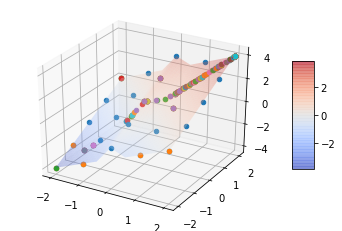

In [15]:
# Driver
#Keeping same landscape/starting point ranges as before

x = -2
c = 0.025
y = 2 + c

# Ploting the landscape with same function as before
#plt.ion()
fig = plt.figure()
ax = DrawSurface(fig, np.arange(x,y,c), np.arange(x,y,c), SimpleLandscape)

# Enter maximum number of iterations of the algorithm, learning rate and mutation range
NumSteps=50
MaxMutate=1

#create arrays of x, y coordinates in specified range (x,y)
xvals = np.array([-2, -1, 0, 1, 2])
yvals = np.array([-2, -1, 0, 1, 2])
xx, yy = np.meshgrid(xvals, yvals)

GlobalOptimum = abs(x)+abs(y)

# Find maximum
HillClimb(xx,yy,NumSteps,MaxMutate,GlobalOptimum,x,y)